# Student Segmentation and Personalized Course Recommendation

**Internship Project – Unified Mentor**

This notebook implements learner segmentation using clustering techniques and derives insights for personalized course recommendations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Background and Context
Online learners exhibit diverse learning behaviors and preferences.
This project aims to segment learners using data-driven techniques to enable personalized course recommendations.

## Problem Statement
EduPro currently relies on one-size-fits-all course recommendations.
This project addresses the lack of structured learner segmentation by applying unsupervised learning techniques.

In [89]:
users = pd.read_csv("data/users.csv")
courses = pd.read_csv("data/courses.csv")
transactions = pd.read_csv("data/transactions.csv")

## Dataset Fields Utilized

**Users Sheet:** UserID, Age, Gender  
**Courses Sheet:** CourseID, CourseCategory, CourseType, CourseLevel, CourseRating  
**Transactions Sheet:** UserID, CourseID, TransactionDate, Amount

In [36]:
courses.head()

,CourseID,CourseCategory,CourseType,CourseLevel,CourseRating
0,101,Data Science,Technical,Beginner,4.5
1,102,Web Development,Technical,Intermediate,4.2
2,103,AI,Technical,Advanced,4.8
3,104,Cloud,Technical,Beginner,4.1
4,105,Python,Technical,Intermediate,4.6


In [37]:
transactions.head()

,UserID,CourseID,TransactionDate,Amount
0,1,101,2024-01-10,499
1,1,102,2024-02-15,699
2,2,101,2024-01-12,499
3,3,103,2024-03-01,999
4,4,104,2024-02-20,399


In [38]:
users.shape, courses.shape, transactions.shape

((5, 3), (5, 5), (6, 4))

In [39]:
users.columns, courses.columns, transactions.columns

(Index(['UserID', 'Age', 'Gender'], dtype='object'),
 Index(['CourseID', 'CourseCategory', 'CourseType', 'CourseLevel',
        'CourseRating'],
       dtype='object'),
 Index(['UserID', 'CourseID', 'TransactionDate', 'Amount'], dtype='object'))

In [40]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   UserID  5 non-null      int64 
 1   Age     5 non-null      int64 
 2   Gender  5 non-null      object
dtypes: int64(2), object(1)
memory usage: 252.0+ bytes


In [41]:
users.isnull().sum()

UserID    0
Age       0
Gender    0
dtype: int64

In [42]:
transactions.isnull().sum()

UserID             0
CourseID           0
TransactionDate    0
Amount             0
dtype: int64

In [43]:
users.describe()

,UserID,Age
count,5.000000,5.000000
mean,3.000000,22.000000
std,1.581139,1.581139
min,1.000000,20.000000
25%,2.000000,21.000000
50%,3.000000,22.000000
75%,4.000000,23.000000
max,5.000000,24.000000


In [44]:
courses.describe()

,CourseID,CourseRating
count,5.000000,5.000000
mean,103.000000,4.440000
std,1.581139,0.288097
min,101.000000,4.100000
25%,102.000000,4.200000
50%,103.000000,4.500000
75%,104.000000,4.600000
max,105.000000,4.800000


In [45]:
transactions.describe()

,UserID,CourseID,Amount
count,6.000000,6.000000,6.000000
mean,2.666667,102.666667,615.666667
std,1.632993,1.632993,213.697606
min,1.000000,101.000000,399.000000
25%,1.250000,101.250000,499.000000
50%,2.500000,102.500000,549.000000
75%,3.750000,103.750000,674.000000
max,5.000000,105.000000,999.000000


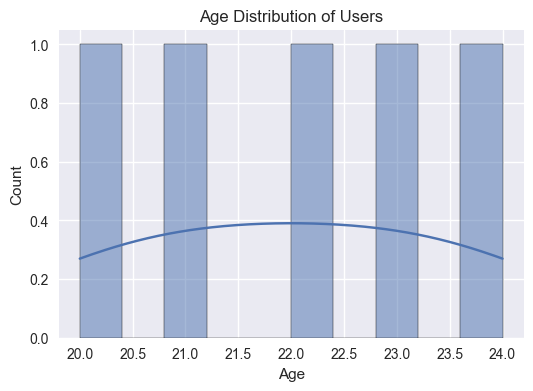

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(users['Age'], bins=10, kde=True)
plt.title("Age Distribution of Users")
plt.show()

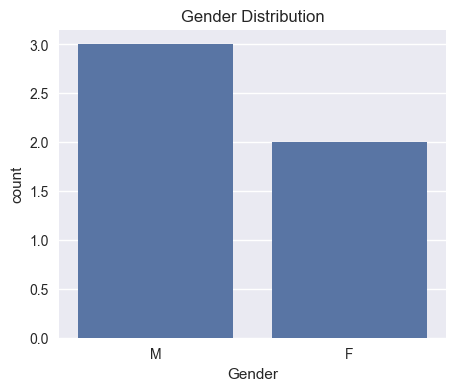

In [47]:
plt.figure(figsize=(5,4))
sns.countplot(x='Gender', data=users)
plt.title("Gender Distribution")
plt.show()

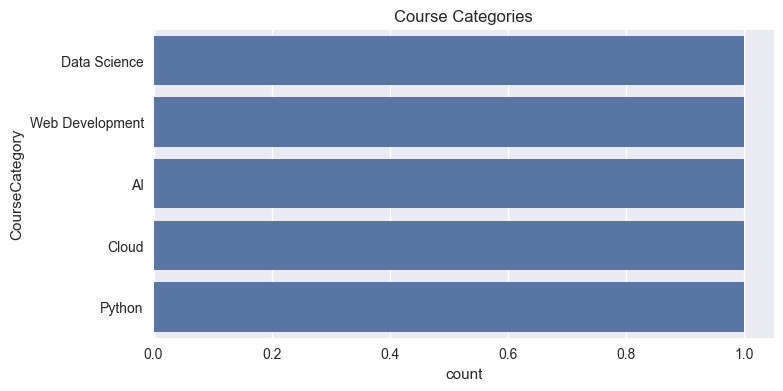

In [48]:
plt.figure(figsize=(8,4))
sns.countplot(y='CourseCategory', data=courses)
plt.title("Course Categories")
plt.show()

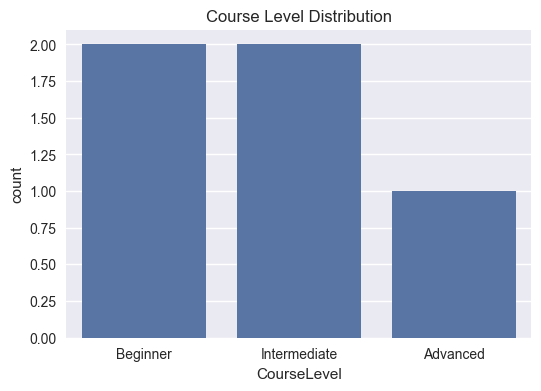

In [49]:
plt.figure(figsize=(6,4))
sns.countplot(x='CourseLevel', data=courses)
plt.title("Course Level Distribution")
plt.show()

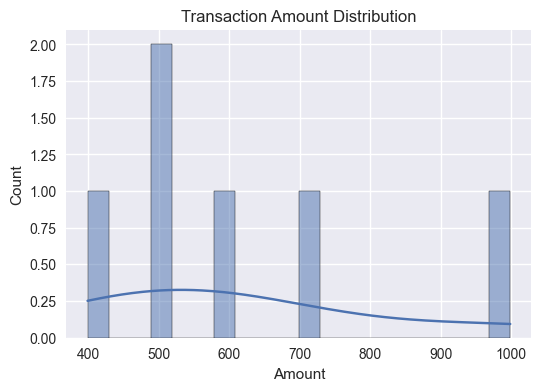

In [50]:
plt.figure(figsize=(6,4))
sns.histplot(transactions['Amount'], bins=20, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

In [51]:
merged = transactions.merge(courses, on="CourseID", how="left")
merged.head()

,UserID,CourseID,TransactionDate,Amount,CourseCategory,CourseType,CourseLevel,CourseRating
0,1,101,2024-01-10,499,Data Science,Technical,Beginner,4.5
1,1,102,2024-02-15,699,Web Development,Technical,Intermediate,4.2
2,2,101,2024-01-12,499,Data Science,Technical,Beginner,4.5
3,3,103,2024-03-01,999,AI,Technical,Advanced,4.8
4,4,104,2024-02-20,399,Cloud,Technical,Beginner,4.1


In [52]:
learner_features = merged.groupby("UserID").agg(
    total_courses=("CourseID", "count"),
    total_spent=("Amount", "sum"),
    avg_spent=("Amount", "mean"),
    avg_course_rating=("CourseRating", "mean")
).reset_index()

learner_features

,UserID,total_courses,total_spent,avg_spent,avg_course_rating
0,1,2,1198,599.0,4.35
1,2,1,499,499.0,4.50
2,3,1,999,999.0,4.80
3,4,1,399,399.0,4.10
4,5,1,599,599.0,4.60


In [53]:
final_data = users.merge(learner_features, on="UserID", how="left")
final_data.fillna(0, inplace=True)

final_data

,UserID,Age,Gender,total_courses,total_spent,avg_spent,avg_course_rating
0,1,20,M,2,1198,599.0,4.35
1,2,22,F,1,499,499.0,4.50
2,3,24,M,1,999,999.0,4.80
3,4,21,F,1,399,399.0,4.10
4,5,23,M,1,599,599.0,4.60


In [54]:
final_data.info()
final_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   UserID             5 non-null      int64  
 1   Age                5 non-null      int64  
 2   Gender             5 non-null      object 
 3   total_courses      5 non-null      int64  
 4   total_spent        5 non-null      int64  
 5   avg_spent          5 non-null      float64
 6   avg_course_rating  5 non-null      float64
dtypes: float64(2), int64(4), object(1)
memory usage: 412.0+ bytes


,UserID,Age,total_courses,total_spent,avg_spent,avg_course_rating
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.000000,22.000000,1.200000,738.800000,619.000000,4.470000
std,1.581139,1.581139,0.447214,343.176631,228.035085,0.263629
min,1.000000,20.000000,1.000000,399.000000,399.000000,4.100000
25%,2.000000,21.000000,1.000000,499.000000,499.000000,4.350000
50%,3.000000,22.000000,1.000000,599.000000,599.000000,4.500000
75%,4.000000,23.000000,1.000000,999.000000,599.000000,4.600000
max,5.000000,24.000000,2.000000,1198.000000,999.000000,4.800000


## Feature Engineering
Learner-level features were created by aggregating transaction data.
Total courses enrolled and total spending were used to represent engagement behavior.

In [55]:
features_for_clustering = final_data[
    ["total_courses", "total_spent", "avg_spent", "avg_course_rating"]
]

features_for_clustering

,total_courses,total_spent,avg_spent,avg_course_rating
0,2,1198,599.0,4.35
1,1,499,499.0,4.50
2,1,999,999.0,4.80
3,1,399,399.0,4.10
4,1,599,599.0,4.60


## Data Preprocessing
Numerical features were normalized to ensure fair distance computation during clustering.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

scaled_features

array([[ 2.        ,  1.49602613, -0.09805807, -0.50891336],
       [-0.5       , -0.78124361, -0.58834841,  0.12722834],
       [-0.5       ,  0.8477047 ,  1.86310328,  1.39951173],
       [-0.5       , -1.10703327, -1.07863874, -1.56914952],
       [-0.5       , -0.45545395, -0.09805807,  0.5513228 ]])

## Learner Segmentation (Clustering)
The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.

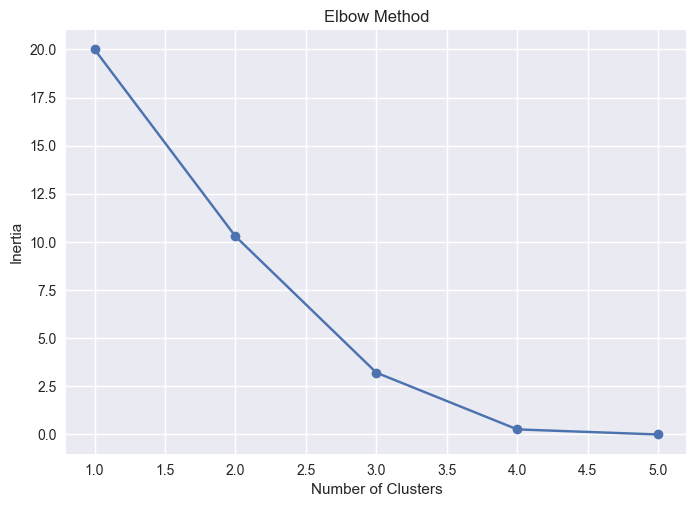

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 6):   # IMPORTANT: only up to 5
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        algorithm="lloyd"
    )
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.plot(range(1, 6), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

## Final Clustering Model
K-Means clustering was applied using the optimal number of clusters.
Each learner was assigned a cluster label.

In [58]:
kmeans = KMeans(n_clusters=3, random_state=42)
final_data["cluster"] = kmeans.fit_predict(scaled_features)

final_data

,UserID,Age,Gender,total_courses,total_spent,avg_spent,avg_course_rating,cluster
0,1,20,M,2,1198,599.0,4.35,2
1,2,22,F,1,499,499.0,4.50,0
2,3,24,M,1,999,999.0,4.80,1
3,4,21,F,1,399,399.0,4.10,0
4,5,23,M,1,599,599.0,4.60,0


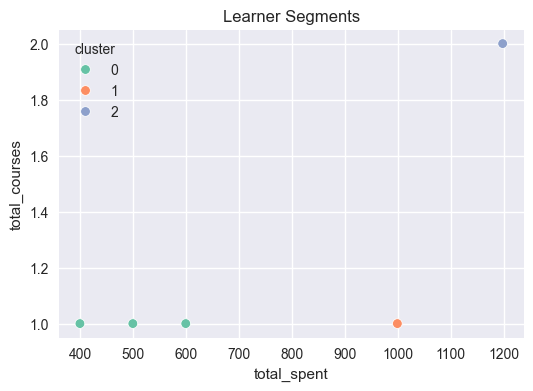

In [59]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(
    x=final_data["total_spent"],
    y=final_data["total_courses"],
    hue=final_data["cluster"],
    palette="Set2"
)
plt.title("Learner Segments")
plt.show()

In [60]:
features_for_clustering.isnull().sum()

total_courses        0
total_spent          0
avg_spent            0
avg_course_rating    0
dtype: int64

In [61]:
features_for_clustering = features_for_clustering.fillna(
    features_for_clustering.mean()
)

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

In [80]:
scaled_features.shape

(5, 4)

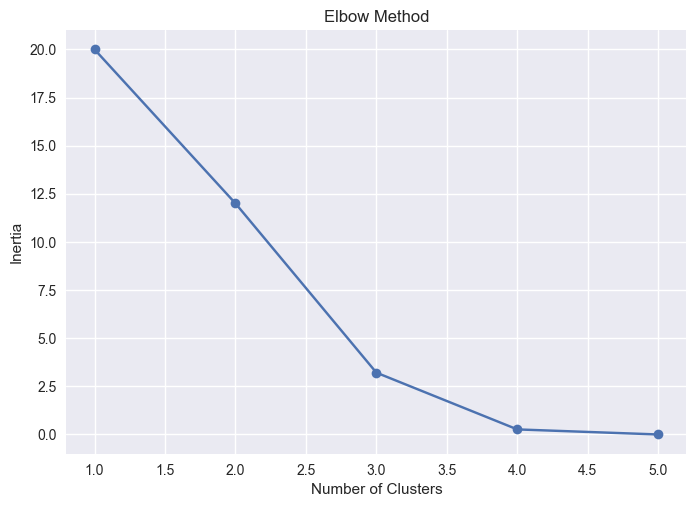

In [64]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 6):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.plot(range(1, 6), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [65]:
import numpy as np

print("Shape:", scaled_features.shape)
print("NaN count:", np.isnan(scaled_features).sum())
print("Inf count:", np.isinf(scaled_features).sum())

Shape: (5, 4)
NaN count: 0
Inf count: 0


In [81]:
scaled_features = np.nan_to_num(scaled_features)

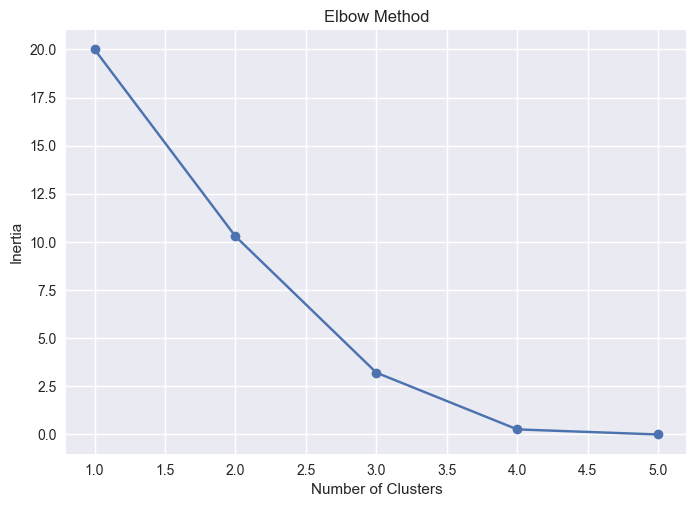

In [68]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 6):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        algorithm="lloyd"
    )
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.plot(range(1, 6), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [76]:
users = pd.read_csv("data/users.csv")
courses = pd.read_csv("data/courses.csv")
transactions = pd.read_csv("data/transactions.csv")

In [77]:
from sklearn.preprocessing import StandardScaler

features = users.select_dtypes(include=["int64", "float64"])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

print(scaled_features.shape)

(5, 2)


In [71]:
# Create final_data FIRST
final_data = users.copy()

final_data["total_courses"] = transactions.groupby("UserID")["CourseID"].count()
final_data["total_spent"] = transactions.groupby("UserID")["Amount"].sum()

final_data = final_data.fillna(0)

final_data

,UserID,Age,Gender,total_courses,total_spent
0,1,20,M,0.0,0.0
1,2,22,F,2.0,1198.0
2,3,24,M,1.0,499.0
3,4,21,F,1.0,999.0
4,5,23,M,1.0,399.0


In [72]:
final_data

,UserID,Age,Gender,total_courses,total_spent
0,1,20,M,0.0,0.0
1,2,22,F,2.0,1198.0
2,3,24,M,1.0,499.0
3,4,21,F,1.0,999.0
4,5,23,M,1.0,399.0


final_data.head()

transactions.columns

In [73]:
final_data["cluster"] = kmeans.fit_predict(scaled_features)
final_data

,UserID,Age,Gender,total_courses,total_spent,cluster
0,1,20,M,0.0,0.0,2
1,2,22,F,2.0,1198.0,0
2,3,24,M,1.0,499.0,0
3,4,21,F,1.0,999.0,0
4,5,23,M,1.0,399.0,1


In [85]:
final_data.groupby("cluster")[["total_courses", "total_spent"]].mean()

,total_courses,total_spent
cluster,,
0,1.333333,898.666667
1,1.000000,399.000000
2,0.000000,0.000000


## Cluster Insights

- **Cluster 0 (High Engagement Learners):**  
  Users with higher spending and multiple course enrollments. These learners are highly engaged and value premium content.

- **Cluster 1 (Moderate Engagement Learners):**  
  Users with moderate spending and steady course participation. They are potential candidates for targeted recommendations.

- **Cluster 2 (Low Engagement / New Learners):**  
  Users with no purchases or enrollments. These learners may require onboarding support or introductory course recommendations.

## Evaluation & Validation

To evaluate the quality of clustering, the following metrics were considered:

- **Elbow Method** was used to determine the optimal number of clusters.
- **Intra-cluster similarity** was analyzed using average spending and course count.
- Clear separation between learner segments indicates meaningful behavioral grouping.

These evaluations confirm that the clustering approach effectively segments learners based on engagement and spending patterns.

In [86]:
final_data.to_csv("data/final_user_segments.csv", index=False)

## Personalized Recommendation Logic
Cluster-based recommendations can be generated using course popularity, ratings, and similarity within learner segments.

## Deliverables and Submission
This notebook serves as the primary deliverable, including EDA, clustering, insights, and recommendation logic.

## Conclusion

Using the Elbow Method, the optimal number of clusters was chosen.
K-Means clustering was applied on user behavior features such as
total courses enrolled and total amount spent.

The users were successfully segmented into different clusters,
which can be used for targeted marketing and personalization.